## Link Images to CSV Data

In [3]:
import os
import numpy as np
import pandas as pd

In [22]:
csv_path = r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\processed\posts.csv"

image_folder = r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\images\original_images"

In [23]:
data = pd.read_csv(csv_path)
data.head()

,post_id,timestamp,ownerUsername,type,caption,hashtags,likesCount,commentsCount,image
0,1,2023-06-02 16:34:43+00:00,maryleest,Sidecar,Cannes 2023 with @kilianparis 🤍 #KilianCannes ...,KilianCannes,32070,142,https://scontent-ord5-1.cdninstagram.com/v/t51...
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,Sidecar,"As the clock struck midnight to ring in 2022, ...",NaN,6565,86,https://instagram.fyei4-1.fna.fbcdn.net/v/t51....
2,3,2023-05-29 18:57:51+00:00,maryleest,Sidecar,The famous stairs 🤎 Photo @gustave_durin Dre...,NaN,28936,123,https://instagram.fpeg1-2.fna.fbcdn.net/v/t51....
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,Sidecar,I visualized this moment so many times before....,CHANELFallWinter,4764,215,https://scontent-lhr8-1.cdninstagram.com/v/t51...
4,5,2023-05-23 21:11:12+00:00,maryleest,Sidecar,Got to witness such historical moment in cinem...,CannesFilmFestival,13379,123,https://instagram.fprg5-1.fna.fbcdn.net/v/t51....


In [24]:
data['local_image_path'] = data['post_id'].apply(lambda x: os.path.join(image_folder, f"{x}.jpg"))

data.drop(columns=['image'], inplace=True)

In [25]:
data.head()

,post_id,timestamp,ownerUsername,type,caption,hashtags,likesCount,commentsCount,local_image_path
0,1,2023-06-02 16:34:43+00:00,maryleest,Sidecar,Cannes 2023 with @kilianparis 🤍 #KilianCannes ...,KilianCannes,32070,142,C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanMan...
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,Sidecar,"As the clock struck midnight to ring in 2022, ...",NaN,6565,86,C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanMan...
2,3,2023-05-29 18:57:51+00:00,maryleest,Sidecar,The famous stairs 🤎 Photo @gustave_durin Dre...,NaN,28936,123,C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanMan...
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,Sidecar,I visualized this moment so many times before....,CHANELFallWinter,4764,215,C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanMan...
4,5,2023-05-23 21:11:12+00:00,maryleest,Sidecar,Got to witness such historical moment in cinem...,CannesFilmFestival,13379,123,C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanMan...


In [26]:
print(data[['post_id', 'local_image_path']].head()) 

   post_id                                   local_image_path
0        1  C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanMan...
1        2  C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanMan...
2        3  C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanMan...
3        4  C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanMan...
4        5  C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanMan...


In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def preprocess_image(image_path, target_size=(224, 224)):
    """
    Đọc ảnh, resize về kích thước target_size và normalize pixel.
    """
    try:
        img = load_img(image_path, target_size=target_size)
        img_array = img_to_array(img)
        img_array = img_array / 255.0
        return img_array
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None

# Ví dụ xử lý ảnh đầu tiên
sample_img = preprocess_image(data['local_image_path'].iloc[0])
print("Kích thước ảnh sau xử lý:", sample_img.shape)

Kích thước ảnh sau xử lý: (224, 224, 3)


In [30]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

base_model = VGG16(weights='imagenet', include_top=False, pooling='avg')

In [31]:
def extract_features(image_path, target_size=(224, 224)):
    """
    Trích xuất vector đặc trưng từ ảnh bằng VGG16.
    """
    try:
        img = load_img(image_path, target_size=target_size)
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)
        features = base_model.predict(img_array)
        return features.flatten()
    except Exception as e:
        print(f"Error extracting features from {image_path}: {e}")
        return np.zeros((base_model.output_shape[1],))

# Áp dụng trích xuất đặc trưng cho ảnh đầu tiên
features_sample = extract_features(data['local_image_path'].iloc[0])
print("Kích thước vector đặc trưng:", features_sample.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
Kích thước vector đặc trưng: (512,)


In [32]:
data.head()

,post_id,timestamp,ownerUsername,type,caption,hashtags,likesCount,commentsCount,local_image_path
0,1,2023-06-02 16:34:43+00:00,maryleest,Sidecar,Cannes 2023 with @kilianparis 🤍 #KilianCannes ...,KilianCannes,32070,142,C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanMan...
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,Sidecar,"As the clock struck midnight to ring in 2022, ...",NaN,6565,86,C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanMan...
2,3,2023-05-29 18:57:51+00:00,maryleest,Sidecar,The famous stairs 🤎 Photo @gustave_durin Dre...,NaN,28936,123,C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanMan...
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,Sidecar,I visualized this moment so many times before....,CHANELFallWinter,4764,215,C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanMan...
4,5,2023-05-23 21:11:12+00:00,maryleest,Sidecar,Got to witness such historical moment in cinem...,CannesFilmFestival,13379,123,C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanMan...


In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 827 entries, 0 to 826
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   post_id           827 non-null    int64 
 1   timestamp         827 non-null    object
 2   ownerUsername     827 non-null    object
 3   type              827 non-null    object
 4   caption           820 non-null    object
 5   hashtags          474 non-null    object
 6   likesCount        827 non-null    int64 
 7   commentsCount     827 non-null    int64 
 8   local_image_path  827 non-null    object
dtypes: int64(3), object(6)
memory usage: 58.3+ KB


In [34]:
# Xử lý dữ liệu null trong hashtags
data['hashtags'] = data['hashtags'].fillna('')
data['hashtags'] = data['hashtags'].apply(lambda x: x.split(','))
data['hashtags'] = data['hashtags'].apply(lambda x: [tag.strip() for tag in x])

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 827 entries, 0 to 826
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   post_id           827 non-null    int64 
 1   timestamp         827 non-null    object
 2   ownerUsername     827 non-null    object
 3   type              827 non-null    object
 4   caption           820 non-null    object
 5   hashtags          827 non-null    object
 6   likesCount        827 non-null    int64 
 7   commentsCount     827 non-null    int64 
 8   local_image_path  827 non-null    object
dtypes: int64(3), object(6)
memory usage: 58.3+ KB


In [7]:
comment = pd.read_csv(r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\processed\posts_comments.csv")
comment.head()

,post_id,comments
0,1,"I have a proposal for u, send me a DM please!"
1,1,Woaaaah
2,1,:smiling_face_with_heart-eyes::smiling_face_wi...
3,1,:red_heart:️:red_heart:️:red_heart:️
4,1,:smiling_face_with_heart-eyes::smiling_face_wi...


In [15]:
print("Số lượng comment:", comment['comments'].notnull().sum())
print("Độ dài comment trung bình:", comment['comments'].dropna().apply(len).mean())

Số lượng comment: 5332
Độ dài comment trung bình: 60.57689422355589


In [16]:
import re
from underthesea import word_tokenize  # hoặc có thể dùng nltk nếu xử lý tiếng Anh

def clean_comment(text):
    if pd.isnull(text):
        return ""
    # Chuyển về chữ thường
    text = text.lower()
    # Loại bỏ URL
    text = re.sub(r'http\S+|www\S+', '', text)
    # Loại bỏ ký tự đặc biệt (giữ lại emoji nếu đã chuyển thành token chữ)
    text = re.sub(r'[^a-zA-Z0-9_ÀÁẠẢÃÂẦẤẬẨẪĂẰẮẶẲẴÈÉẸẺẼÊỀẾỆỂỄÌÍỊỈĨÒÓỌỎÕÔỒỐỘỔỖƠỜỚỢỞỠÙÚỤỦŨƯỪỨỰỬỮỲÝỴỶỸĐ\s:]', '', text)
    # Xóa khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Áp dụng cho cột comment
comment['clean_comment'] = comment['comments'].apply(clean_comment)
print(comment[['comments', 'clean_comment']].head())


c:\Python\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                                            comments  \
0      I have a proposal for u, send me a DM please!   
1                                            Woaaaah   
2  :smiling_face_with_heart-eyes::smiling_face_wi...   
3               :red_heart:️:red_heart:️:red_heart:️   
4  :smiling_face_with_heart-eyes::smiling_face_wi...   

                                       clean_comment  
0        i have a proposal for u send me a dm please  
1                                            woaaaah  
2  :smiling_face_with_hearteyes::smiling_face_wit...  
3                  :red_heart::red_heart::red_heart:  
4  :smiling_face_with_hearteyes::smiling_face_wit...  


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf.fit_transform(comment['clean_comment'])
print("Ma trận TF-IDF có kích thước:", tfidf_matrix.shape)


Ma trận TF-IDF có kích thước: (5432, 1000)


In [18]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...


In [19]:
# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

In [21]:
# Apply VADER on the cleaned comment text to compute sentiment scores
comment['sentiment_scores'] = comment['clean_comment'].apply(lambda x: sia.polarity_scores(x))

print(comment['sentiment_scores'].iloc[0])


{'neg': 0.0, 'neu': 0.723, 'pos': 0.277, 'compound': 0.3182}


In [26]:
# Define a function to label sentiment based on compound score
def get_sentiment_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Extract the compound score from the sentiment_scores dictionary
comment['compound_score'] = comment['sentiment_scores'].apply(lambda x: x['compound'])

# Create a new column with the sentiment label
comment['sentiment_label'] = comment['compound_score'].apply(get_sentiment_label)

# Inspect the results
print(comment[['clean_comment', 'compound_score', 'sentiment_label']].head())


                                       clean_comment  compound_score  \
0        i have a proposal for u send me a dm please          0.3182   
1                                            woaaaah          0.0000   
2  :smiling_face_with_hearteyes::smiling_face_wit...          0.0000   
3                  :red_heart::red_heart::red_heart:          0.0000   
4  :smiling_face_with_hearteyes::smiling_face_wit...          0.5095   

  sentiment_label  
0        positive  
1         neutral  
2         neutral  
3         neutral  
4        positive  


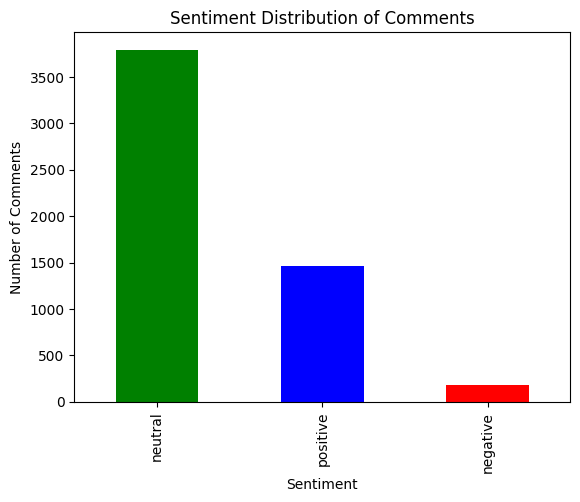

In [27]:
import matplotlib.pyplot as plt

# Count the number of comments for each sentiment label
sentiment_counts = comment['sentiment_label'].value_counts()
sentiment_counts.plot(kind='bar', color=['green', 'blue', 'red'])
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.title('Sentiment Distribution of Comments')
plt.show()
